# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [119]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [121]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 0.51            # Thickness of each vertical bar
d_angles = 10 * np.ones(len(np.arange(0, 180, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [122]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [123]:
# Compute the union of the survey geometries and simplify the result
survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [124]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (565470.42276 5834824.618155)


In [125]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_1088017/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


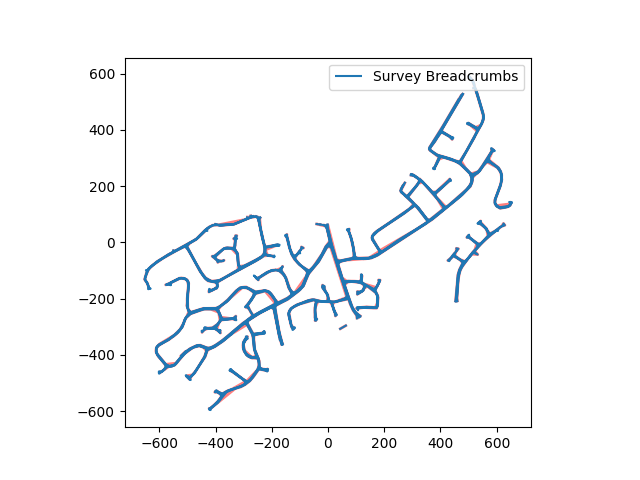

In [126]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

In [127]:
center.x

565470.42276

# Generate the grid

In [128]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [129]:
import time
start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
angle = 0

#d_angles = np.array([10])
# Parameters for evenly spaced thin vertical rectangles (grid "bars")
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Define a rotation angle in radians (example: 45 degrees)

            if angle == 0:
                rotation_matrix = np.array([
                    [1,0],
                    [0,1]
                ])
            else:
                theta = np.deg2rad(d_angle)
                rotation_matrix = np.array([
                    [np.cos(theta), -np.sin(theta)],
                    [np.sin(theta), np.cos(theta)]])
                grid_lines_gdf['geometry'] = grid_lines_gdf['geometry'].rotate(angle=d_angle, origin=(0,0))

            start_rotate = time.perf_counter()
            # Rotate the vector by the rotation matrix
            rotated_vec = rotation_matrix @ current_vec
            ortho_vec = rotation_matrix @ current_ortho_vec

            end_rotate = time.perf_counter()

            # Rotate the grid lines accordingly
            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                survey_union_offset_gdf, 
                how='intersection', 
                keep_geom_type=False
            )
            end_intersection = time.perf_counter()
            print(f'Time to rotate: {end_rotate - start_rotate}')
            print(f'Time to intersection: {end_intersection - end_rotate}')
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)

            start_bottom = time.perf_counter()

            intersection_gdf['r0'] = intersection_gdf['geometry'].rotate(angle=-angle, origin=(0,0))
            intersection_gdf['bottom_points'] = intersection_gdf['r0'].apply(lambda geom: get_bottom_two_points(geom,angle))


            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))
            end_angle = time.perf_counter()
            print(f'Time to angle: {end_angle - start_bottom}')

            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle'], 0, atol=tol_deg)]
            if len(right_angles) > 0:
                #print('There is a right angle')
                #Get the cell boundaries
                right_angles['cell_boundary'] = right_angles.apply(lambda row: get_line_from_angle(row, ortho_vec), axis=1)

                #Rename the grid_idx to include the angle
                right_angles['grid_idx'] = right_angles.apply(lambda row: f"{row['grid_idx']}_{angle}", axis=1)
                right_angles.reset_index(drop=True)
                output_gdf = pd.concat([output_gdf, right_angles])

            angle = angle + d_angle
            current_vec = rotated_vec
            current_ortho_vec = ortho_vec

construction_start = time.perf_counter()

# Remove entries whose cell_boundary length > 1 std above the mean
lengths = output_gdf.cell_boundary.length
mean_length = lengths.mean()
std_length = lengths.std()
filtered_output_gdf = output_gdf[lengths <= (mean_length + std_length/2)]


#Remove all the intersecting 
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in output_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})
construction_end = time.perf_counter()
print(f'Time to construct: {construction_end - construction_start}')


Processing angle:  0
Time to rotate: 2.26310221478343e-05
Time to intersection: 0.1525592069956474
Time to angle: 0.32555258099455386
Processing angle:  10.0
Time to rotate: 2.8306967578828335e-05
Time to intersection: 0.31936963199405
Time to angle: 0.3145125500159338
Processing angle:  20.0
Time to rotate: 2.845597919076681e-05
Time to intersection: 0.45983153802808374
Time to angle: 0.33528195100370795
Processing angle:  30.0
Time to rotate: 4.363799234852195e-05
Time to intersection: 0.5633741900091991
Time to angle: 0.33629931596806273
Processing angle:  40.0
Time to rotate: 3.007001942023635e-05
Time to intersection: 0.671531084983144
Time to angle: 0.4553031219984405
Processing angle:  50.0
Time to rotate: 2.2360007278621197e-05
Time to intersection: 0.6715622029732913
Time to angle: 0.33727166400058195
Processing angle:  60.0
Time to rotate: 2.9489980079233646e-05
Time to intersection: 0.6083550300099887
Time to angle: 0.3494412599829957
Processing angle:  70.0
Time to rotate: 

## Count the intersections by cell

In [130]:
# For each cell, create an inner offset to prevent bad counts
cell_offset_gdf = gpd.GeoDataFrame(geometry=cell_gdf.buffer(-0.1).explode(index_parts=False), crs=cell_gdf.crs)
cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)

/tmp/ipykernel_1088017/1053509735.py:3: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)


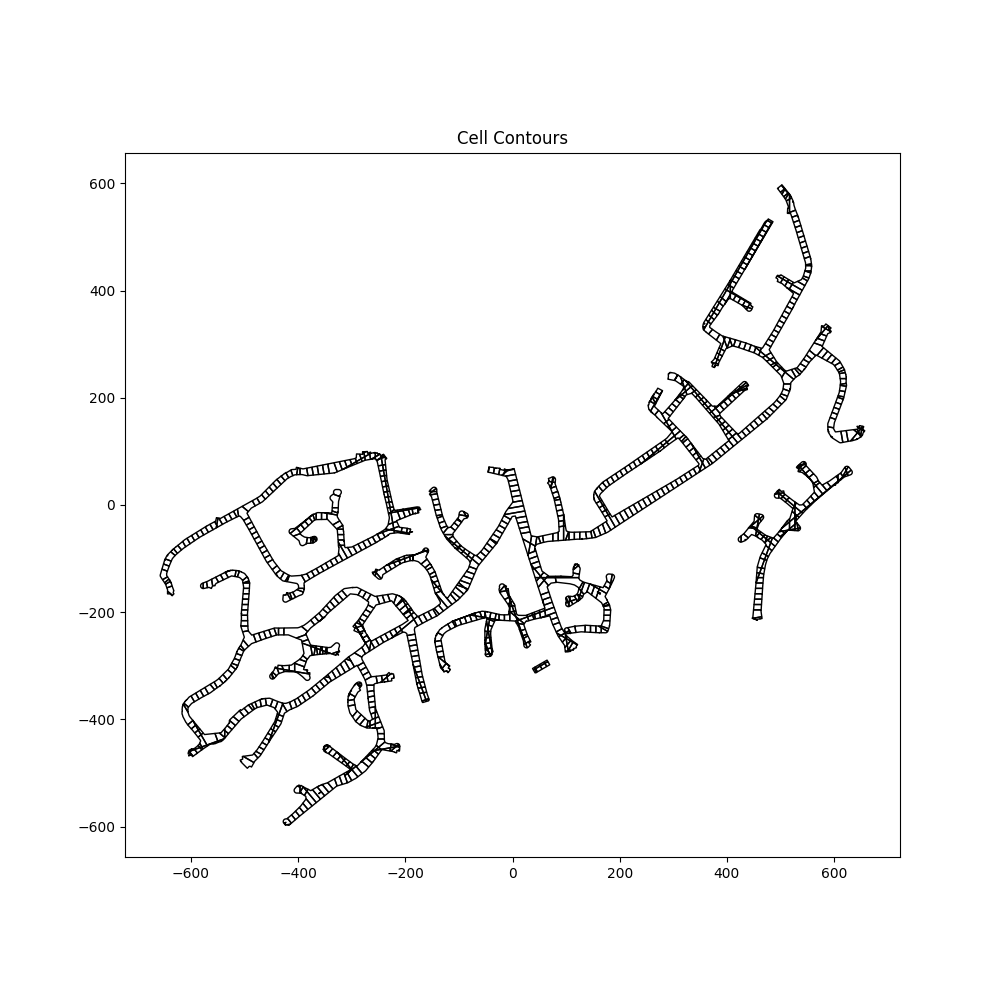

In [131]:
# Plot the cell polygons as contours (outlines) rather than filled polygons
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
cell_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title('Cell Contours')
ax.set_aspect('equal')
plt.show()

In [132]:

#For each cell, partition the polygon into segments along its boundary lines using exterior coordinates. This will help us to get the nummber of boundaries
segment_list = []
for poly in cell_offset_gdf.geometry:
    coords = list(poly.exterior.coords)
    for i in range(len(coords) - 1):
        seg = LineString([coords[i], coords[i+1]])
        segment_list.append(seg)

partitioned_gdf = gpd.GeoDataFrame(geometry=segment_list, crs=cell_offset_gdf.crs)

#Get the intersections of the surveys with the boundaries
points = gpd.GeoDataFrame(
    gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),
    crs=survey_gdf.crs
)
points = points.set_geometry('geometry')
points_buffer = gpd.GeoDataFrame(geometry=points.buffer(0.05), crs=points.crs)

#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')


/tmp/ipykernel_1088017/336621587.py:13: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),


In [133]:
#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')
# Fix: Only cast to int if value is finite (not NA/inf) to avoid IntCastingNaNError
if boundaries['index_left'].notnull().all():
    boundaries['index_left'] = boundaries['index_left'].astype(int)
else:
    # Fill NA with a placeholder (e.g., -1) before casting, or just keep NA if that's acceptable
    boundaries['index_left'] = boundaries['index_left'].fillna(-1).astype(int)
    # Drop rows where index_left == -1
boundaries = boundaries[boundaries['index_left'] != -1]
boundaries.rename(columns={'index_left': 'points_idx'}, inplace=True)
# Get unique geometries from 'boundaries' and put in a GeoDataFrame
unique_geoms = boundaries['geometry'].unique()
unique_gdf = gpd.GeoDataFrame(geometry=list(unique_geoms), crs=boundaries.crs)
unique_gdf.reset_index(drop=True, inplace=True)
joined_gdf_unique = gpd.sjoin(unique_gdf, cell_gdf, how='right', predicate='intersects')
boundary_counts = joined_gdf_unique.groupby('cell_idx').size().reset_index(name='boundaries')

# Get the number of intersections per cell
joined_gdf = gpd.sjoin(points, cell_gdf, how='left', predicate='intersects')
# Get intersection counts by cell
intersection_counts = joined_gdf.groupby('cell_idx').size().reset_index(name='intersections')
intersection_boundaties = intersection_counts.merge(boundary_counts, left_on='cell_idx', right_on='cell_idx', how='left')

#Get the output
cell_summary = cell_gdf.merge(intersection_boundaties, left_on='cell_idx', right_on='cell_idx', how='left')
cell_summary['passes'] = cell_summary['intersections'] / cell_summary['boundaries']

/tmp/ipykernel_1088017/575504383.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axa.legend()


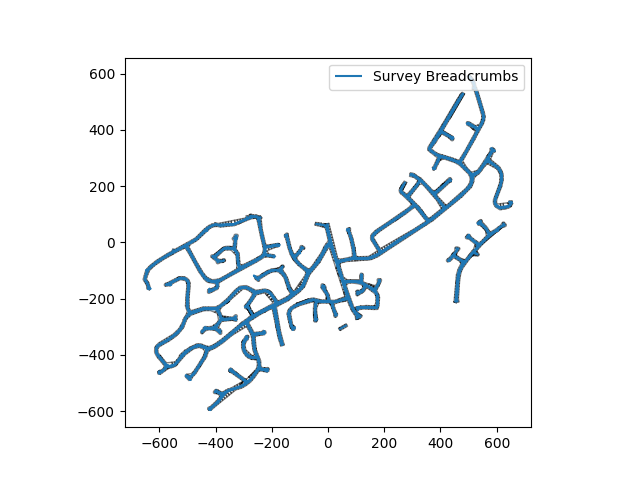

In [134]:
fig,axa = plt.subplots()
cell_gdf.plot(edgecolor='black', facecolor='none', alpha=0.5, ax=axa, label='Grid Cells')
survey_gdf.plot(ax=axa, label='Survey Breadcrumbs')
axa.legend()

In [135]:
# Use geopandas's dissolve to aggregate geometries by the 'passes' column
# This will produce a GeoDataFrame with one row per unique 'passes' value, with multipolygons where appropriate.

# Create a new GeoDataFrame with necessary columns
cell_info_nonan = cell_summary.dropna(subset=['passes']).copy()

dissolved = cell_info_nonan.dissolve(by='passes')

# Ensure the dissolved result is a GeoDataFrame indexed by 'passes'
aggregated_cells_by_pass_gdf = dissolved.reset_index()[['passes', 'geometry']]

/tmp/ipykernel_1088017/1960337944.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


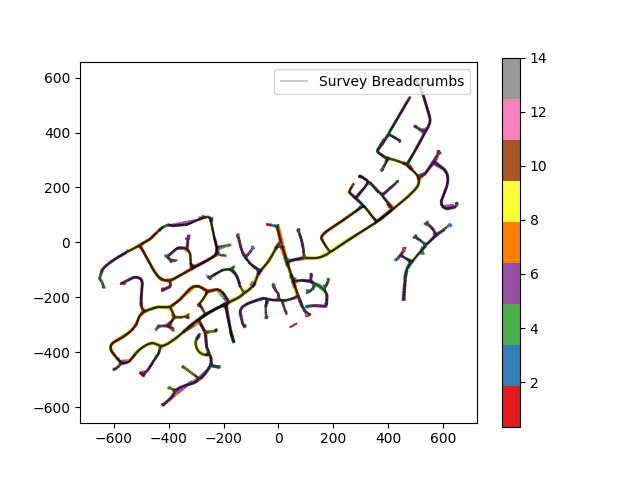

In [136]:
fig, ax = plt.subplots()
plot = cell_summary.plot(column='passes', cmap='Set1', ax=ax, legend=True, label='Number of passes')
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs', color='black', alpha=0.2)
# Set title for colorbar
if plot.get_legend() is not None and hasattr(plot.get_legend(), 'set_title'):
    plot.get_legend().set_title('number of passes')
ax.legend()

In [137]:
aggregated_cells_by_pass_gdf['geometry'] = aggregated_cells_by_pass_gdf.translate(xoff=center.x, yoff=center.y)

In [138]:
survey_4326 = survey_gdf.copy()

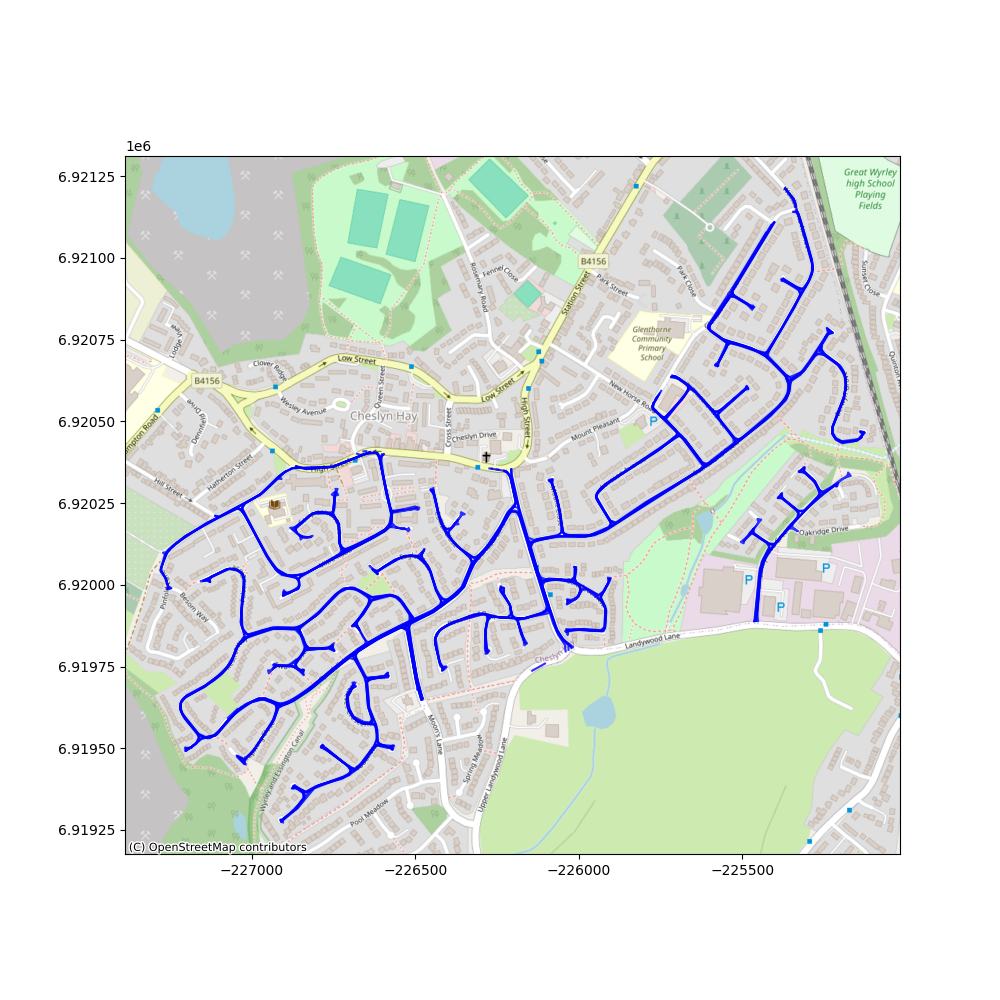

In [139]:
import contextily as ctx

# Project to Web Mercator for plotting with basemap
survey_webmerc = survey_4326.set_geometry('Breadcrumb_wkt').to_crs('EPSG:3857')
ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


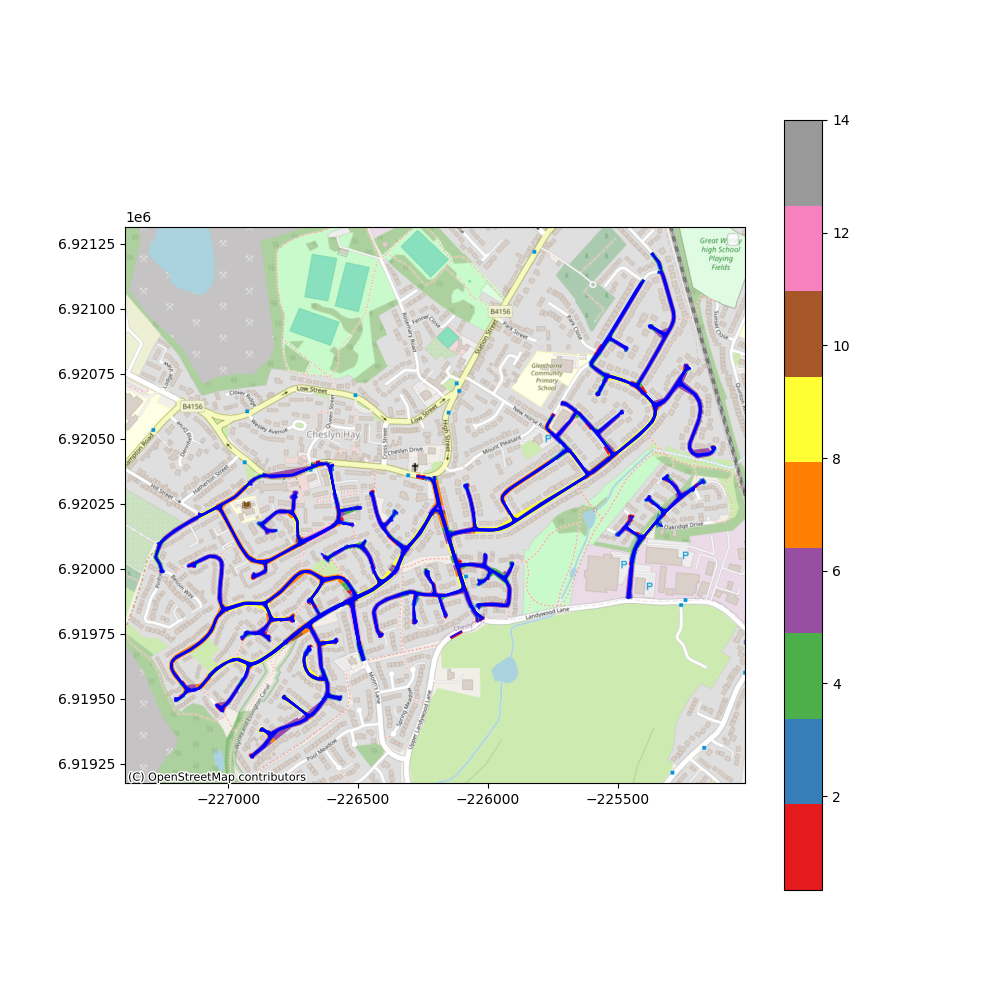

In [140]:
agg = aggregated_cells_by_pass_gdf.to_crs('EPSG:3857')
import contextily as ctx

ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ax = agg.plot(ax = ax, figsize=(10, 10), column='passes', cmap='Set1', legend=True)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()

In [141]:
cell_summary['passes'].value_counts()

passes
6.000000     314
8.000000     124
7.000000     104
4.000000      96
2.000000      61
1.000000      60
9.000000      46
3.000000      29
5.000000      25
3.333333      24
5.333333      19
4.666667      19
11.000000     16
10.000000     15
6.666667      14
1.333333      14
7.333333      12
2.666667       9
14.000000      9
3.500000       5
1.500000       5
4.500000       4
2.500000       4
5.500000       3
0.571429       3
2.800000       2
2.333333       2
6.500000       2
0.333333       1
10.666667      1
1.666667       1
3.200000       1
0.666667       1
0.705882       1
0.750000       1
9.333333       1
0.625000       1
1.764706       1
0.480000       1
0.370370       1
1.090909       1
0.428571       1
8.500000       1
0.640000       1
0.470588       1
0.600000       1
7.500000       1
9.500000       1
3.600000       1
0.444444       1
0.833333       1
1.400000       1
1.285714       1
1.600000       1
Name: count, dtype: int64